# Data Exploration: Genre Story Generator Dataset

This notebook provides a comprehensive exploratory data analysis (EDA) of the genre story dataset, with notes aligned to the project proposal (conditional generation, preprocessing, and evaluation).
Dataset source: https://huggingface.co/datasets/FareedKhan/1k_stories_100_genre

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set styling
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load dataset (local CSV required)
data_path = Path("../data/1k_stories_100_genre.csv")
if not data_path.exists():
    raise FileNotFoundError(
        "Local CSV not found. Please place `1k_stories_100_genre.csv` in the `../data/` folder as required by the project proposal."
    )
df = pd.read_csv(data_path)

print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nColumn names:\n{df.columns.tolist()}")

Dataset loaded: 1000 rows, 4 columns

Column names:
['id', 'title', 'story', 'genre']


## 0. Dataset Source and Schema

This dataset provides a genre label and full story text. For conditional generation, inputs will later combine a genre label and a short prompt (e.g., story prefix) and the full story will be the target output. The notebook requires the local CSV `../data/1k_stories_100_genre.csv` as described in the project proposal.

In [ ]:
df.sample(3, random_state=42)[["genre", "story"]]

## 1. Dataset Quality Assessment

In [ ]:
# Check for missing values and data types
print("Missing Values:")
print(df.isnull().sum())
print(f"\nMissing Value Percentage:")
print((df.isnull().sum() / len(df) * 100).round(2))

print(f"\n{'='*50}")
print("Data Types:")
print(df.dtypes)

print(f"\n{'='*50}")
print("Duplicate Rows:")
print(f"Total duplicates: {df.duplicated().sum()}")

print(f"\n{'='*50}")
print("First few rows:")
display(df.head())

Missing Values:
id       0
title    0
story    0
genre    0
dtype: int64

Missing Value Percentage:
id       0.0
title    0.0
story    0.0
genre    0.0
dtype: float64

Data Types:
id       int64
title      str
story      str
genre      str
dtype: object

Duplicate Rows:
Total duplicates: 0

First few rows:


,id,title,story,genre
0,457580,The Chronicles of the Cosmic Rift,"In the year 2250, Earth had made significant s...",Science Fiction
1,297904,Eldoria's Enchanted Whispers,"In a land far away, where the sun shone bright...",Fantasy
2,620436,Echoes of Whispered Shadows,"Once upon a time, in a small, tranquil town ca...",Mystery
3,634687,Emerald Amulet Chronicles Revealed,"Once upon a time in the 16th century, a small ...",Historical Adventure
4,513427,The Shadows of St. Augustine,In the sun-drenched coastal city of St. August...,Thriller


## 2. Story Length Analysis

In [ ]:
df["word_count"] = df["story"].apply(lambda x: len(str(x).split()))
print(df["word_count"].describe())

# Add a prefix field to be used as prompt (e.g., first 30 words)
PROMPT_WORDS = 30
def extract_prefix(text, n_words=PROMPT_WORDS):
    tokens = str(text).split()
    return " ".join(tokens[:n_words])
df["prompt_prefix"] = df["story"].apply(lambda s: extract_prefix(s, PROMPT_WORDS))
print("\nSample prompt prefixes:")
display(df[["prompt_prefix"]].sample(3, random_state=42))

count    1000.000000
mean      985.861000
std       430.611272
min        83.000000
25%       804.000000
50%       978.500000
75%      1163.500000
max      3093.000000
Name: word_count, dtype: float64


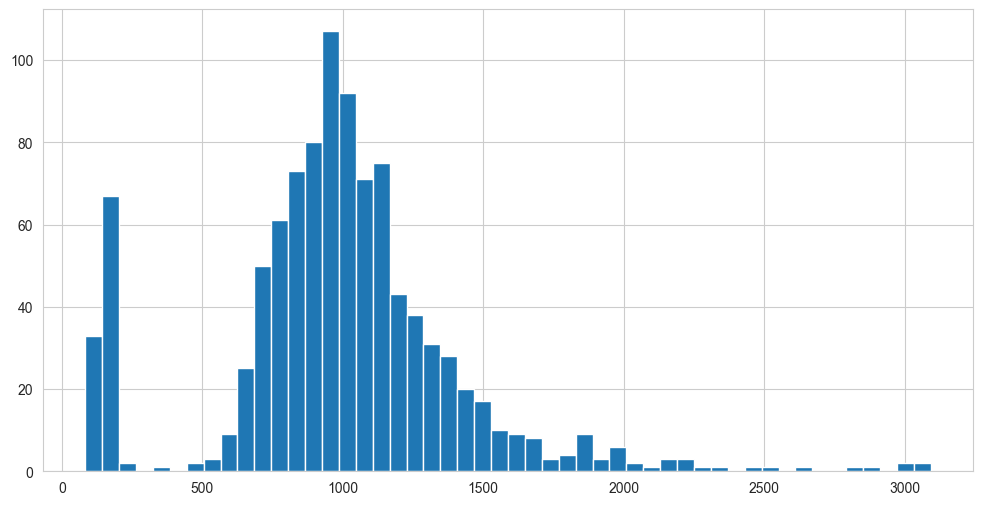

In [ ]:
df["word_count"].hist(bins=50)
plt.title("Story Length Distribution (words)")
plt.xlabel("Word count")
plt.ylabel("Number of stories")
plt.show()

In [ ]:
# longest and shortest stories
print(f"Longest story: \n{df.loc[df["word_count"].idxmax(), ['genre','word_count']]}")
print(f"\n{'='*50}")
print(f"\nShortest story: \n{df.loc[df["word_count"].idxmin(), ['genre','word_count']]}")

Longest story: 
id                                                       800612
title                                       Shadows of the Mind
story         In the sleepy town of Elmswood, life seemed to...
genre                                    Psychological Thriller
word_count                                                 3093
Name: 438, dtype: object


Shortest story: 
id                                                       173546
title                                    Rainforest's Last Song
story         In the dense and lush expanse of the Amazon ra...
genre                                             Environmental
word_count                                                   83
Name: 747, dtype: object


## 3. Genre Balance Analysis

In [ ]:
df["genre"].value_counts()

genre
Historical Adventure    20
Science Fiction         10
Fantasy                 10
Mystery                 10
Thriller                10
                        ..
Space Exploration       10
Steampunk Fantasy       10
Noir Comedy             10
Social Commentary       10
Techno-Mystery          10
Name: count, Length: 99, dtype: int64

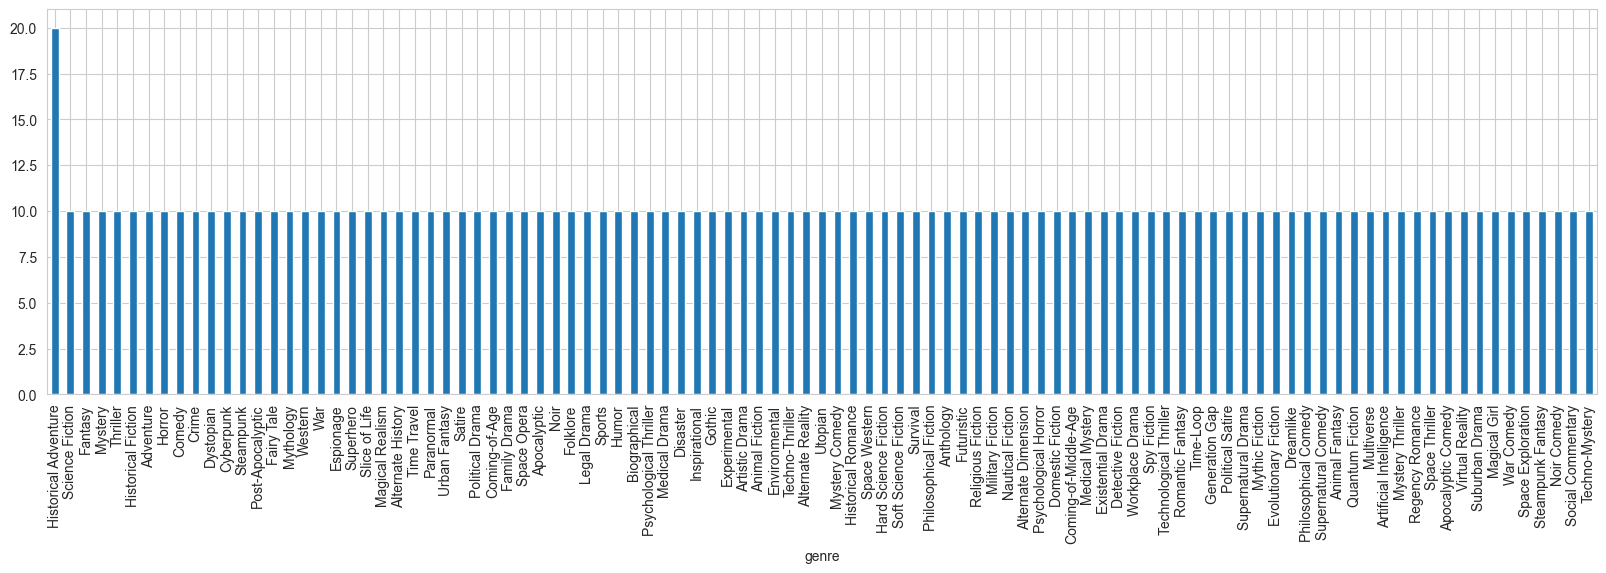

In [ ]:
df["genre"].value_counts().plot(kind="bar", figsize=(20,5))
plt.title("Genre Distribution")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.show()

## 4. Vocabulary Analysis

**Insight**: Understanding the vocabulary size helps determine tokenizer settings and embedding dimensions for model architecture.

In [ ]:
counter = Counter()

for story in df["story"]:
    counter.update(str(story).lower().split())

print("Vocab size:", len(counter))

Vocab size: 33698


In [ ]:
# Create train/validation split and save samples for downstream preprocessing
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(df, test_size=0.1, random_state=42, stratify=df['genre'])
print(f"Train: {len(train_df)}, Val: {len(val_df)}")

# Save small samples for quick checks
out_dir = Path("../data/processed")
out_dir.mkdir(parents=True, exist_ok=True)
train_df.sample(50, random_state=42)[["genre","prompt_prefix","story"]].to_csv(out_dir / "train_sample.csv", index=False)
val_df.sample(50, random_state=42)[["genre","prompt_prefix","story"]].to_csv(out_dir / "val_sample.csv", index=False)
print(f"Saved sample CSVs to {out_dir}")

## Key Insights & Findings

1. DATA QUALITY 

   • Requires local CSV at `../data/1k_stories_100_genre.csv`
   • Check for missing values and duplicates before training

2. GENRE DISTRIBUTION
   • 99 unique genres in the dataset
   • Most genres contain around 10 stories
   • Distribution is relatively balanced overall

3. STORY LENGTH PATTERNS
   • Average story length: 986 words (approx)
   • Range: 83–3093 words
   • 95th percentile: 1669 words
   • Long sequence lengths may require truncation during training

4. VOCABULARY CHARACTERISTICS
   • Total vocabulary size: 33,698 unique words (approx)
   • Large vocabulary suggests the need for special token handling (<UNK>, <PAD>, etc.)
   • Text contains diverse writing styles and genre-specific language

5. CONDITIONAL GENERATION SETUP
   • Inputs will combine a genre label and a short prompt prefix (first 30 words)
   • The story text serves as the target output for teacher-forced training

6. NEXT STEPS
   • Create preprocessing script `data.py` to produce `train.csv` and `val.csv` with columns: `genre`, `prompt`, `story`
   • Tokenizer selection and max sequence length experiments
   • Build training pipeline following `train.py` and `model.py` from proposal